# Homework 4

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False

np.set_printoptions(precision=4, suppress=True)


def top_k(score_dict, k=10):
    return sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:k]


def plot_graph_with_labels(G, title, node_values=None):
    pos = nx.kamada_kawai_layout(G)
    plt.figure(figsize=(11, 7))

    if node_values is None:
        node_values = {n: 1.0 for n in G.nodes()}

    values = np.array([node_values[n] for n in G.nodes()], dtype=float)
    if values.max() > 0:
        sizes = 500 + 2500 * values / values.max()
    else:
        sizes = 500

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=sizes,
        node_color=values,
        cmap="viridis",
    )

    widths = []
    for _, _, data in G.edges(data=True):
        widths.append(0.5 + float(data.get("weight", 1.0)) * 0.15)

    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.colorbar(nodes, label="Node value")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_graph_partition(G, parts, title, layout=None):
    S, T = parts
    if layout is None:
        layout = nx.kamada_kawai_layout(G)

    colors = ["skyblue" if n in S else "orange" for n in G.nodes()]
    sizes = [450 + 60 * G.degree(n, weight="weight") for n in G.nodes()]

    plt.figure(figsize=(11, 7))
    nx.draw_networkx_edges(G, layout, alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(G, layout, node_color=colors, node_size=sizes)
    nx.draw_networkx_labels(G, layout, font_size=8)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 1. Select a dense labeled graph

Full graph: 77 nodes, 254 edges
Connected: True, density: 0.0868
Selected subgraph: 24 nodes, 88 edges
Density of selected undirected subgraph: 0.319


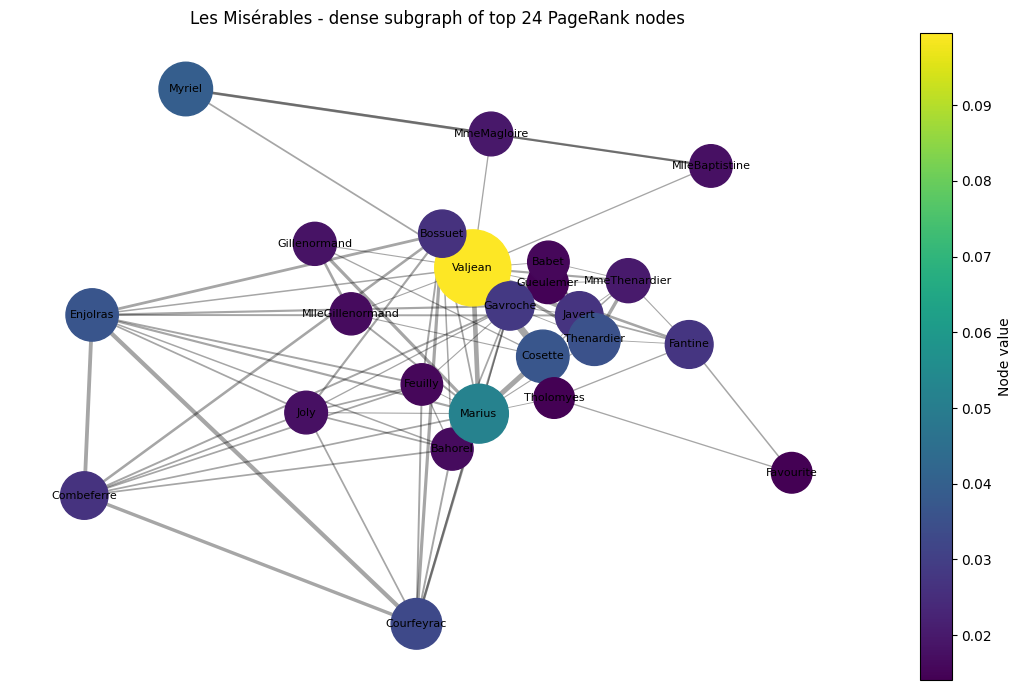

In [2]:
G = nx.les_miserables_graph()

print(f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected: {nx.is_connected(G)}, density: {nx.density(G):.4f}")

K = 24

pr_full = nx.pagerank(G, alpha=0.85, weight="weight")
selected_nodes = [n for n, _ in top_k(pr_full, k=K)]
H = G.subgraph(selected_nodes).copy()

print(f"Selected subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
print(f"Density of selected undirected subgraph: {nx.density(H):.3f}")

plot_graph_with_labels(
    H,
    f"Les Misérables - dense subgraph of top {K} PageRank nodes",
    node_values={n: pr_full[n] for n in H.nodes()},
)

## 2) Adjacency matrix and HITS

In [3]:
HD = H.to_directed() # (eredetileg iranyitatlan, ha A szerepel B-vel akkor B is szerepel A-val egy fejezetben)

nodes = list(HD.nodes())
A_dir = nx.to_numpy_array(HD, nodelist=nodes, weight="weight", dtype=float)

# HITS with builtin networkx
hubs_nx, auth_nx = nx.hits(HD, max_iter=5000, tol=1e-12, normalized=True)

# HITS with SVD
U, s, VT = np.linalg.svd(A_dir, full_matrices=False)

hub_svd = np.abs(U[:, 0])
auth_svd = np.abs(VT.T[:, 0])

hub_svd = hub_svd / hub_svd.sum()
auth_svd = auth_svd / auth_svd.sum()

hub_svd_dict = dict(zip(nodes, hub_svd))
auth_svd_dict = dict(zip(nodes, auth_svd))

print("Top-10 hubs (nx.hits):")
for n, v in top_k(hubs_nx, k=10):
    print(f"  {n:20s} {v:.5f}")

print("\nTop-10 authorities (nx.hits):")
for n, v in top_k(auth_nx, k=10):
    print(f"  {n:20s} {v:.5f}")

print("\nTop-10 hubs (SVD):")
for n, v in top_k(hub_svd_dict, k=10):
    print(f"  {n:20s} {v:.5f}")

print("\nTop-10 authorities (SVD):")
for n, v in top_k(auth_svd_dict, k=10):
    print(f"  {n:20s} {v:.5f}")

Top-10 hubs (nx.hits):
  Valjean              0.12035
  Marius               0.11299
  Cosette              0.10147
  Enjolras             0.08114
  Courfeyrac           0.07505
  Combeferre           0.06335
  Bossuet              0.05877
  Javert               0.04788
  Gavroche             0.04342
  Thenardier           0.04014

Top-10 authorities (nx.hits):
  Valjean              0.12035
  Marius               0.11299
  Cosette              0.10147
  Enjolras             0.08114
  Courfeyrac           0.07505
  Combeferre           0.06335
  Bossuet              0.05877
  Javert               0.04788
  Gavroche             0.04342
  Thenardier           0.04014

Top-10 hubs (SVD):
  Valjean              0.12035
  Marius               0.11299
  Cosette              0.10147
  Enjolras             0.08114
  Courfeyrac           0.07505
  Combeferre           0.06335
  Bossuet              0.05877
  Javert               0.04788
  Gavroche             0.04342
  Thenardier           0.04

## 3) Laplacian matrix, eigenvalues/eigenvectors, Fiedler vector

In [4]:
A = nx.to_numpy_array(H, weight="weight", dtype=float)

deg = A.sum(axis=1)
L = np.diag(deg) - A

w, V = np.linalg.eigh(L)
idx = np.argsort(w)
w = w[idx]
V = V[:, idx]

print("Smallest Laplacian eigenvalues:")
print(w[:10])

fiedler = V[:, 1]

nodes_u = list(H.nodes())
fi = list(zip(nodes_u, fiedler))
fi_sorted = sorted(fi, key=lambda kv: kv[1])

print("\nMost negative Fiedler coords:")
for n, v in fi_sorted[:10]:
    print(f"  {n:20s} {v:.5f}")

print("\nMost positive Fiedler coords:")
for n, v in fi_sorted[-10:][::-1]:
    print(f"  {n:20s} {v:.5f}")

Smallest Laplacian eigenvalues:
[ 0.      3.3351  3.6019  6.6113  9.9924 10.6015 16.9222 22.1008 23.6127
 26.    ]

Most negative Fiedler coords:
  Favourite            -0.65068
  Tholomyes            -0.53506
  Fantine              -0.19487
  Javert               -0.00524
  MmeThenardier        -0.00229
  Thenardier           0.00694
  Babet                0.01393
  Cosette              0.01437
  Gueulemer            0.01541
  Valjean              0.02275

Most positive Fiedler coords:
  MlleBaptistine       0.28285
  MmeMagloire          0.28109
  Myriel               0.26379
  Bahorel              0.05370
  Feuilly              0.05354
  Joly                 0.05293
  Bossuet              0.04949
  Combeferre           0.04932
  Courfeyrac           0.04818
  Gavroche             0.04629


## 4) Partition the graph and check meaningfulness

In [5]:
def partition_by_sign(vec, nodes):
    pos = [n for n, x in zip(nodes, vec) if x >= 0]
    neg = [n for n, x in zip(nodes, vec) if x < 0]
    return [set(pos), set(neg)]

parts_f = partition_by_sign(fiedler, nodes_u)

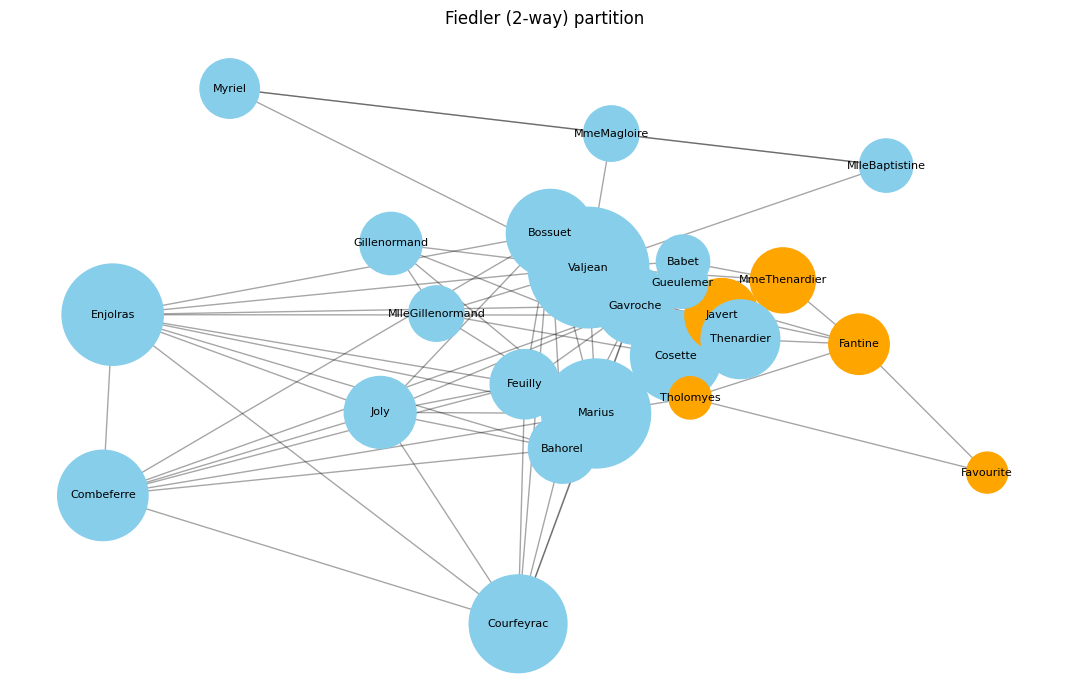

In [6]:
layout = nx.kamada_kawai_layout(H)
plot_graph_partition(H, parts_f, title="Fiedler (2-way) partition", layout=layout)

## 5) Is the partition meaningful?

To see whether the partition is “meaningful”, it helps to compare how important nodes split across the two sides.

Below we print the top nodes by weighted degree and by PageRank for each side of the Fiedler split.

In [7]:
S, T = parts_f

deg_w = dict(H.degree(weight="weight"))
pr = nx.pagerank(H, alpha=0.85, weight="weight")


def top_in(part, score_dict, k=10):
    items = [(n, score_dict[n]) for n in part]
    return sorted(items, key=lambda kv: kv[1], reverse=True)[:k]

print("Fiedler split sizes:", len(S), len(T))

print("\nTop weighted-degree nodes in S:")
for n, v in top_in(S, deg_w, 10):
    print(f"  {n:20s} deg_w={v:.2f}")

print("\nTop weighted-degree nodes in T:")
for n, v in top_in(T, deg_w, 10):
    print(f"  {n:20s} deg_w={v:.2f}")

print("\nTop PageRank nodes in S:")
for n, v in top_in(S, pr, 10):
    print(f"  {n:20s} pr={v:.5f}")

print("\nTop PageRank nodes in T:")
for n, v in top_in(T, pr, 10):
    print(f"  {n:20s} pr={v:.5f}")

Fiedler split sizes: 19 5

Top weighted-degree nodes in S:
  Valjean              deg_w=118.00
  Marius               deg_w=95.00
  Enjolras             deg_w=81.00
  Courfeyrac           deg_w=75.00
  Cosette              deg_w=64.00
  Combeferre           deg_w=63.00
  Bossuet              deg_w=59.00
  Thenardier           deg_w=46.00
  Gavroche             deg_w=44.00
  Joly                 deg_w=37.00

Top weighted-degree nodes in T:
  Javert               deg_w=39.00
  MmeThenardier        deg_w=29.00
  Fantine              deg_w=24.00
  Tholomyes            deg_w=8.00
  Favourite            deg_w=7.00

Top PageRank nodes in S:
  Valjean              pr=0.11435
  Marius               pr=0.08365
  Enjolras             pr=0.06638
  Courfeyrac           pr=0.06086
  Cosette              pr=0.05986
  Combeferre           pr=0.05190
  Thenardier           pr=0.05069
  Bossuet              pr=0.04923
  Gavroche             pr=0.03946
  Myriel               pr=0.03420

Top PageRank node